Paquetes necesarios

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

Variables importantes

In [2]:
#Lee imagen de archivo
img = cv2.imread('mandril.jpg')              # foto del mandril (bgr)
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # mandril en escala de grises
canny = cv2.Canny(gris, 100, 200)            # detección de contornos del mandril con canny

ggris = cv2.GaussianBlur(gris, (3, 3), 0)    # gaussiana
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # sobel x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # sobel y
sobel = cv2.add(sobelx, sobely)              # sobel total

### **TAREA 1**

Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

(0.0, 512.0)

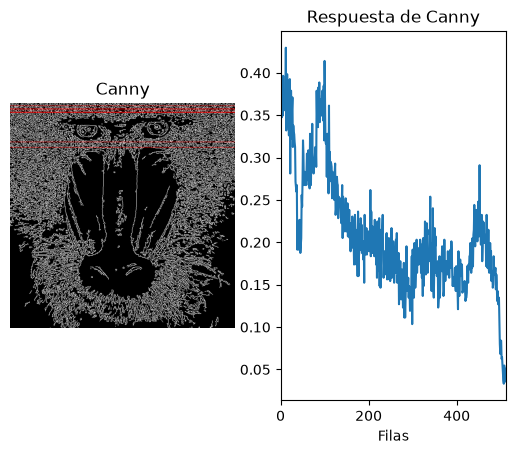

In [3]:
# Cuenta el número de píxeles blancos (255) por columna
# Suma los valores de los pixeles por columna
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

# Normaliza en base al número de filas y al valor máximo del píxel (255)
# El resultado será el número de píxeles blancos por columna
rows = row_counts[:,0] / (255 * canny.shape[1])

max_value = np.max(rows)
highlight = np.where(rows >= max_value*0.9)[0]

canny_rgb = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR)
for i in highlight:
    cv2.line(canny_rgb, (0, i), (canny.shape[1], i), (255, 0, 0))


plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny_rgb, cmap='gray') 

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows)

#Rango en y definido por las filas
plt.xlim([0, canny.shape[0]])


### **TAREA 2**
Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobel tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

(0.0, 512.0)

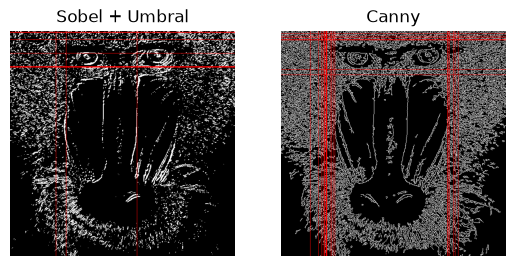

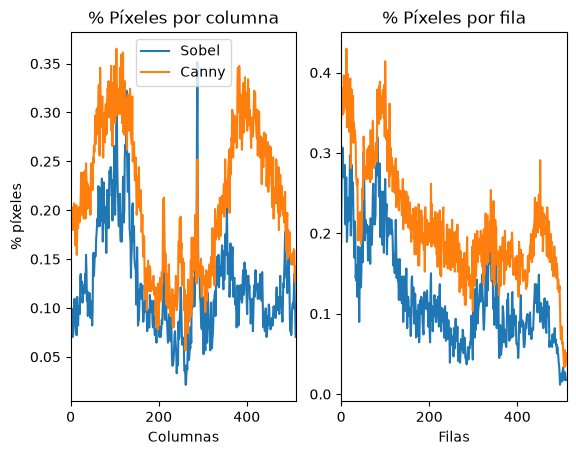

In [ ]:
sobel_abs = cv2.convertScaleAbs(sobel)
_, sobel_thresh = cv2.threshold(sobel_abs, 128, 255, cv2.THRESH_BINARY)

col_counts = cv2.reduce(sobel_thresh, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
cols_sobel = col_counts[0] / (255 * sobel_thresh.shape[0])

row_counts = cv2.reduce(sobel_thresh, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
rows_sobel = row_counts[:, 0] / (255 * sobel_thresh.shape[1])


max_row = np.max(rows_sobel)
highlight_rows = np.where(rows_sobel >= max_row*0.9)[0]

max_col = np.max(cols_sobel)
highlight_cols = np.where(cols_sobel >= max_col*0.9)[0]


sobel_rgb = cv2.cvtColor(sobel_thresh, cv2.COLOR_GRAY2RGB)

for y in highlight_rows:
    cv2.line(sobel_rgb, (0, y), (sobel_rgb.shape[1], y), (255, 0, 0))

for x in highlight_cols:
    cv2.line(sobel_rgb, (x, 0), (x, sobel_rgb.shape[0]), (255, 0, 0))



# ======== Canny ====================================================
col_counts = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
cols = col_counts[0] / (255 * canny.shape[0])

max_value = np.max(cols)
highlight = np.where(cols > max_value*0.9)[0]

for x in highlight:
    cv2.line(canny_rgb, (x, 0), (x, canny.shape[0]), (255, 0, 0))

# ===============================================================


plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Sobel + Umbral")
plt.imshow(sobel_rgb)

plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny_rgb) 

plt.figure()
plt.subplot(1, 2, 1)
plt.title("% Píxeles por columna")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(cols_sobel, label="Sobel")
plt.plot(cols, label="Canny")
plt.xlim([0, sobel_thresh.shape[1]])

plt.subplot(1, 2, 2)
plt.title("% Píxeles por fila")
plt.xlabel("Filas")
plt.ylabel("")
plt.plot(rows_sobel)
plt.plot(rows)
plt.xlim([0, sobel_thresh.shape[0]])

handles, labels = plt.gca().get_legend_handles_labels()
plt.figlegend(handles, labels, loc="lower center", ncol=2)
plt.tight_layout(rect=[0, 0.08, 1, 1])   # deja hueco abajo para la leyenda
plt.show()


Se puede observar que, tanto en el caso de las filas como en el de las columnas, Canny interpreta alrededor de un 5% más de píxeles que Sobel tras el umbralizado.

---

Diferencia de imágenes

In [ ]:
#Calcula la diferencia entre dos imágenes
#Utiliza la imagen original y la obtenida tras aplicar la gaussiana (creada en la celda dedicada a Sobel)
dif = cv2.absdiff(gris, ggris)

#Visualiza
plt.figure()
plt.subplot(1, 2, 1)
plt.title("Diferencias")
plt.axis("off")
plt.imshow(dif, cmap='gray') 

#Zonas de mayor diferencia tras aplicar umbral
res, imgdif = cv2.threshold(dif, 30, 255, cv2.THRESH_BINARY)
#Visualiza
plt.subplot(1, 2, 2)
plt.title("Mayores")
plt.axis("off")
plt.imshow(imgdif, cmap='gray') 
plt.show()


Webcam y sustracción de fotogramas

In [ ]:
vid = cv2.VideoCapture(0)

#Marca de inicio
disponible = 0 
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        if disponible > 0:
            dif = cv2.absdiff(frame, pframe)        
            # Muestra resultado
            cv2.imshow('Diferencia', dif)    
        else:
            disponible = 1

        #Copia fotograma actual para la diferencia en el siguiente forograma
        pframe = frame.copy()
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

Webcam y sustracción de modelo del fondo

In [ ]:
vid = cv2.VideoCapture(0)

# Fondo
# Inicializa la sustracción del fondo con mezcla de gaussianas y detección de sombras
eliminadorFondo = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=50, detectShadows=True)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        # Aplica efecto espejo sobre la entrada
        framem=cv2.flip(frame, 1)
        
        #Con un segundo parámerto se puede definir máscara con zonas a actualizar
        objetos = eliminadorFondo.apply(framem)
        # objetos = eliminadorFondo.apply(framem, objetos, 0)  #No actualiza el fondo
        # Obtiene fondo
        background = eliminadorFondo.getBackgroundImage()

        # Muestra resultado
        cv2.imshow('Fotograma', objetos)
        # Muestra fondo
        cv2.imshow('Fondo', background)
  
   
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [10]:
vid = cv2.VideoCapture(0)
bgRemover = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=100, detectShadows=True)


while (True):
    ret, frame = vid.read()

    if ret:
        emarf = cv2.flip(frame, 1)
        bg = bgRemover.apply(emarf)
        _, thresh = cv2.threshold(bg, 128, 255, cv2.THRESH_BINARY)

        col_counts = cv2.reduce(thresh, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
        cols = col_counts[0] / (255 * thresh.shape[0])

        max_value = np.max(cols)
        highlight = np.where(cols > 0.02)[0]

        if len(highlight) > 0:
            x_min, x_max = highlight[0], highlight[-1]
            cv2.rectangle(emarf, (x_min, 0), (x_max, emarf.shape[0]), (0, 0, 0), -1)

        cv2.imshow('Cortina', emarf)
    
    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()